In [1]:
# main

import loader as ld
import processing as proc
import vizualization as viz
import models as mod
import pandas as pd

data = ld.load_csv('e:/oil_price.csv')



CSV файл e:/oil_price.csv загружен.


In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

data.head()

,date,price
0,1983-03-01 00:00:00+00:00,29.27
1,1983-04-01 00:00:00+00:00,30.63
2,1983-05-01 00:00:00+00:00,30.25
3,1983-06-01 00:00:00+00:00,31.38
4,1983-07-01 00:00:00+00:00,32.00


In [3]:
#Преобразование колонки с датой в формат datetime
data = proc.datetime(data)
print(data.head())

            price
date             
1983-03-01  29.27
1983-04-01  30.63
1983-05-01  30.25
1983-06-01  31.38
1983-07-01  32.00


In [4]:
proc.info(data)


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 517 entries, 1983-03-01 to 2026-03-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   517 non-null    float64
dtypes: float64(1)
memory usage: 8.1 KB


In [5]:
proc.date_type(data)



 Типы данных и пропущенные значения:


,Data Type,Missing values,Missing %,Unique Values
price,float64,0,0.0,490


<Figure size 1700x400 with 0 Axes>

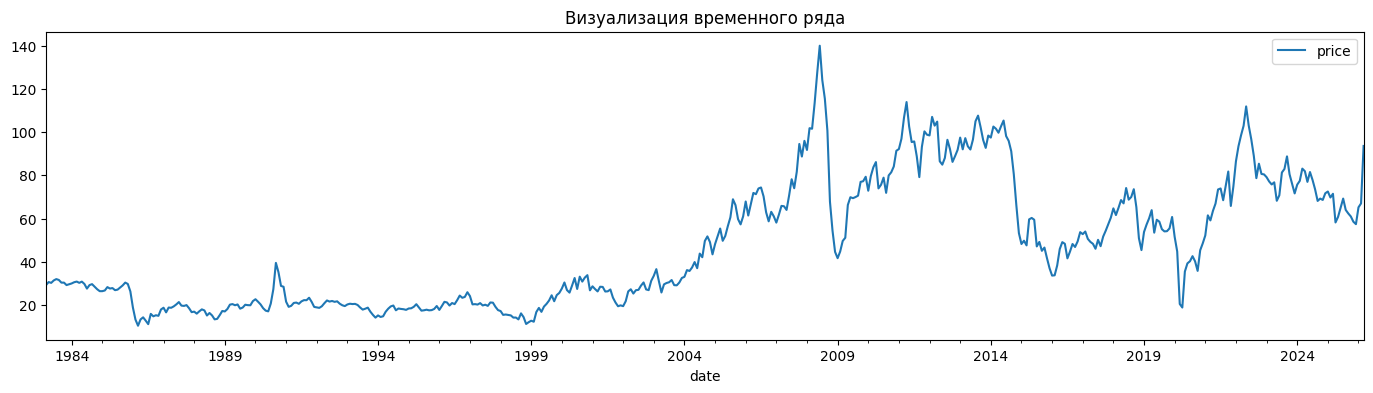

In [6]:
# Построение исходных данных
plt.figure(figsize=(17, 4))
data.plot(figsize=(17, 4), title='Визуализация временного ряда')
plt.show()

Проверка аномалий STL-декомпозицией (Seasonal-Trend decomposition)

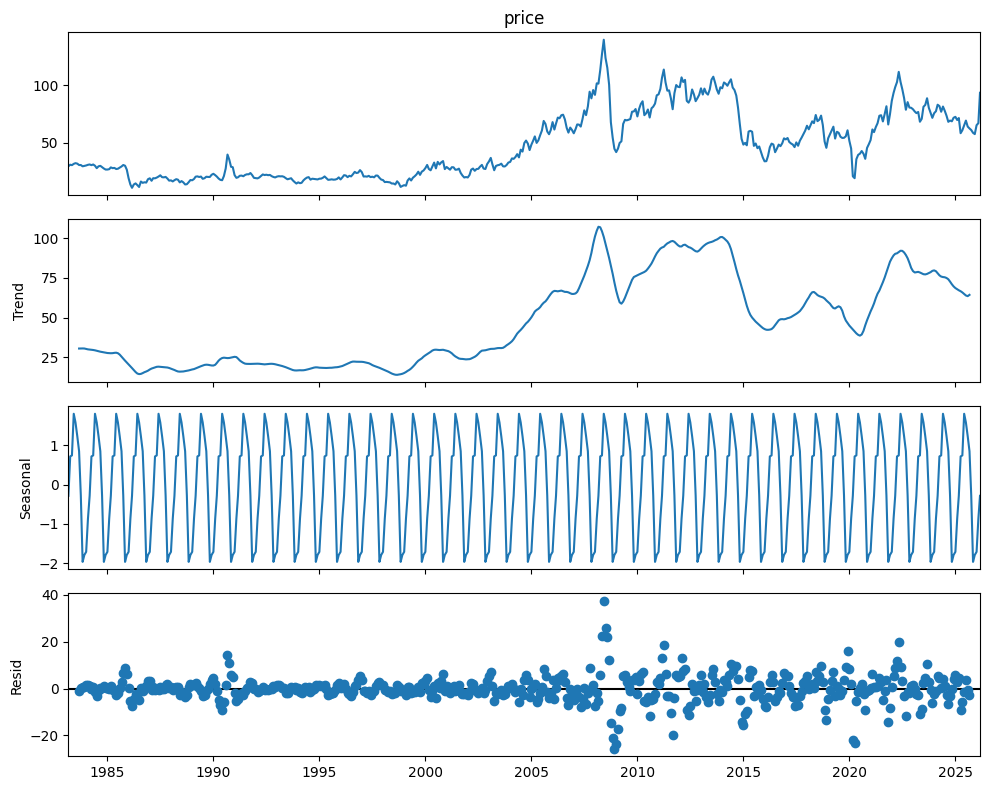

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
# Декомпозиция (период 12 месяцев)
result = seasonal_decompose(data['price'], model='additive', period=12)

# Визуализация
plt.rcParams['figure.figsize'] = (10, 8)
result.plot()
plt.show()

In [8]:
#Тест на стационарность (Тест Дики-Фуллера)
proc.testDF(data)


ADF Statistic: -2.1531
p-value: 0.2237
Ряд нестационарен (требуется дифференцирование)


In [9]:
#Автоматическое определение d
proc.autoD(data)



Исходный p-value: 0.2237
После 1-го порядка дифференцирования p-value: 0.0000

Ряд стал стационарным. Рекомендуемый параметр d = 1


#d = 1: У ряда есть линейный тренд. Можно использовать ARIMA(p, 1, q).

In [10]:
! pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00


In [10]:
dict_models = {}

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3121.005, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3144.215, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3126.453, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3127.887, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3142.527, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3130.150, Time=0.17 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3130.250, Time=0.16 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3122.957, Time=0.51 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=3122.936, Time=0.42 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3128.325, Time=0.08 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3123.365, Time=0.27 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3121.271, Time=0.34 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=3125.005, Time=0.43 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=3119.720, Time=0.20 sec
 ARIMA(1,1,2)(0,0,0)[0]          

c:\Users\OITKostya\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\OITKostya\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


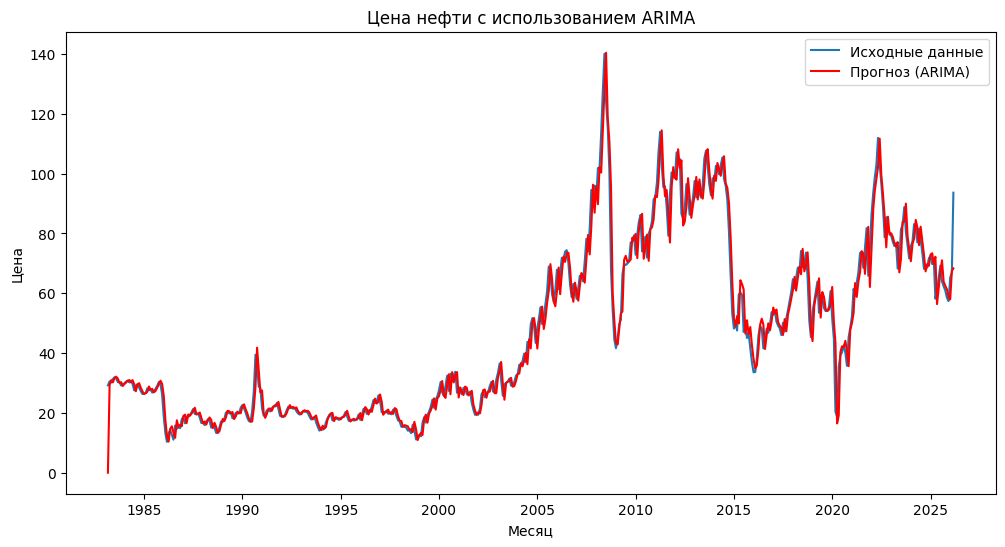

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  517
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1554.860
Date:                Wed, 18 Mar 2026   AIC                           3119.720
Time:                        14:50:20   BIC                           3140.951
Sample:                    03-01-1983   HQIC                          3128.040
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4147      0.114     12.395      0.000       1.191       1.638
ar.L2         -0.5009      0.114     -4.407      0.000      -0.724      -0.278
ma.L1         -1.2373      0.134     -9.222      0.0

In [11]:
# Автоматический поиск лучших параметров (auto_arima)
# seasonal=True и m=12 годовая сезонность
model_auto = mod.model_autoArima(data)


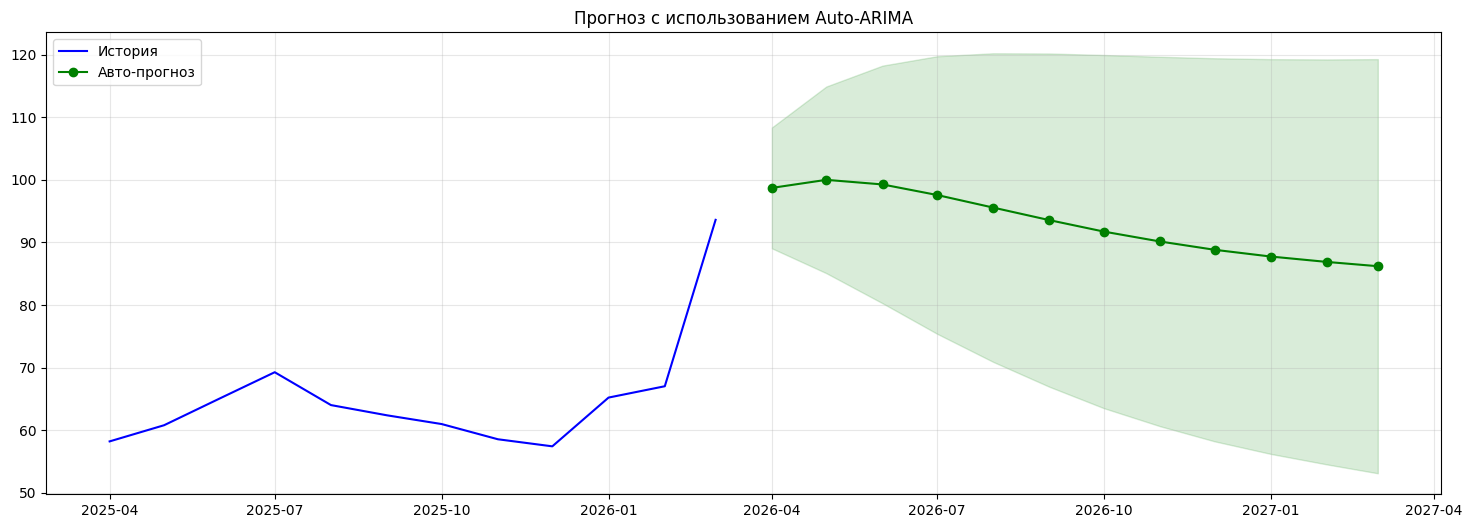

In [12]:
# Построение прогноза на следующие 12 месяцев
forecast, conf_int, forecast_index = mod.pred_autoArima(model_auto, 12, data)



**Кросс-валидация Rolling Forecast модели auto-ARIMA. Тестирование осуществлялось на последних 24 месяцах**

Запуск скользящего прогноза (это может занять время)...
Месяц 1/24: Предсказано=84.42, Реально=81.93
Месяц 2/24: Предсказано=81.86, Реально=76.99
Месяц 3/24: Предсказано=75.89, Реально=81.54
Месяц 4/24: Предсказано=82.15, Реально=77.91
Месяц 5/24: Предсказано=77.30, Реально=73.55
Месяц 6/24: Предсказано=72.63, Реально=68.17
Месяц 7/24: Предсказано=67.16, Реально=69.26
Месяц 8/24: Предсказано=69.65, Реально=68.63
Месяц 9/24: Предсказано=69.02, Реально=71.72
Месяц 10/24: Предсказано=72.79, Реально=72.53
Месяц 11/24: Предсказано=73.20, Реально=69.76
Месяц 12/24: Предсказано=69.60, Реально=71.48
Месяц 13/24: Предсказано=72.02, Реально=58.21
Месяц 14/24: Предсказано=56.15, Реально=60.79
Месяц 15/24: Предсказано=61.41, Реально=65.11
Месяц 16/24: Предсказано=66.65, Реально=69.26
Месяц 17/24: Предсказано=70.79, Реально=64.01
Месяц 18/24: Предсказано=63.64, Реально=62.37
Месяц 19/24: Предсказано=62.34, Реально=60.98
Месяц 20/24: Предсказано=61.14, Реально=58.55
Месяц 21/24: Предсказано=58.60, Р

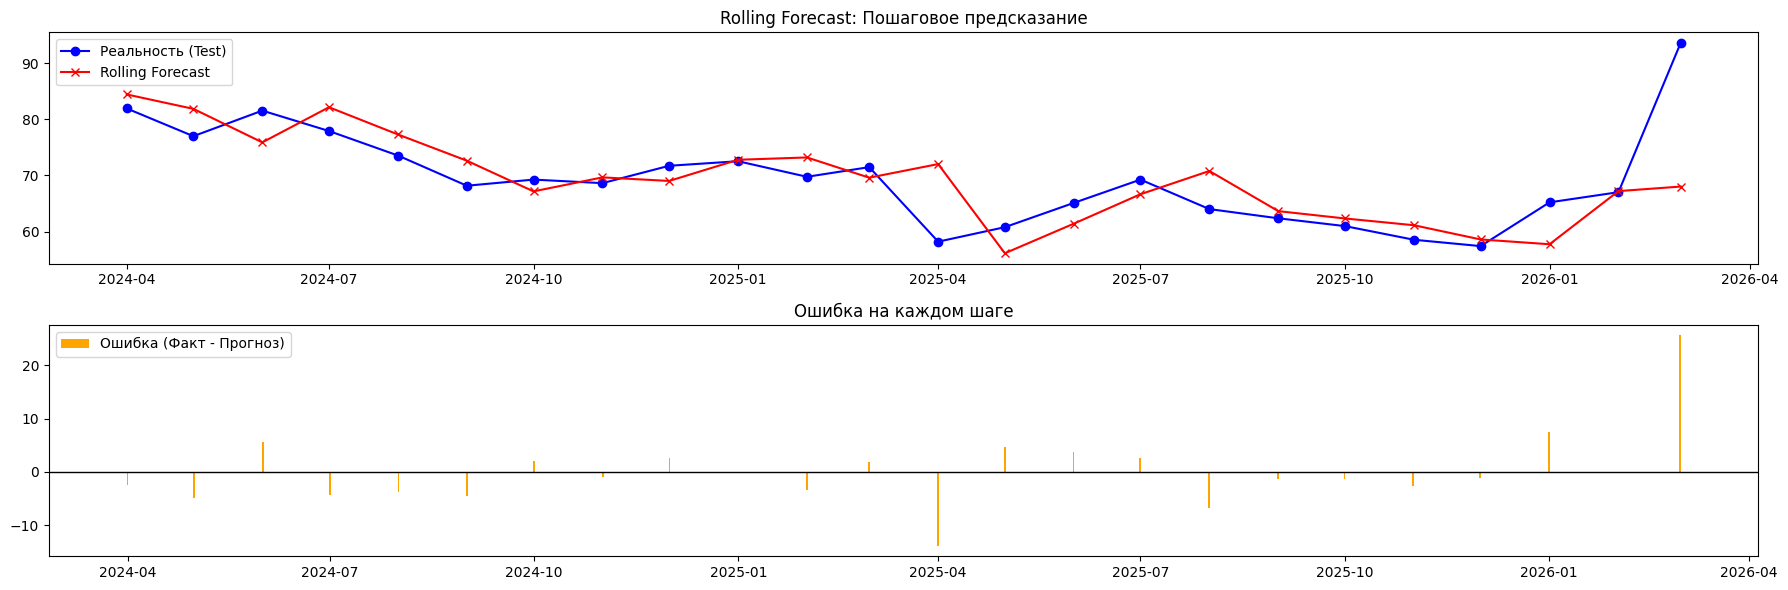

In [13]:
#Кросс-валидация Rolling Forecast модели
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import pandas as pd
from sklearn.metrics import mean_absolute_error

history = list(data['price'][:-24]) # Начальное обучение
test = data['price'][-24:]          # Тест
predictions = []
print("Запуск скользящего прогноза (это может занять время)...")
# Цикл скользящего прогноза
for t in range(len(test)):
    # Обучаем модель на всей доступной истории
    model = auto_arima(history, seasonal=False, suppress_warnings=True, error_action="ignore")

    # Прогнозируем 1 следующий шаг
    yhat = model.predict(n_periods=1)[0]
    predictions.append(yhat)

    # Добавляем реальное значение из теста в историю для следующей итерации
    history.append(test.iloc[t])
    print(f"Месяц {t+1}/24: Предсказано={yhat:.2f}, Реально={test.iloc[t]:.2f}")
# Оценка точности
rolling_mae = mean_absolute_error(test, predictions)
print(f"\nСредняя ошибка (MAE) скользящего прогноза: {rolling_mae:.2f}")
#Добавляем в справочник ошибок
dict_models["ARIMA"] = rolling_mae

# Превращаем в Series для графика
pred_series = pd.Series(predictions, index=test.index)
plt.figure(figsize=(18, 6))

# Основной график сравнения
plt.subplot(2, 1, 1)

plt.plot(test.index, test, label='Реальность (Test)', color='blue', marker='o')
plt.plot(pred_series.index, pred_series, label='Rolling Forecast', color='red', marker='x')
plt.title('Rolling Forecast: Пошаговое предсказание')
plt.legend()

# График ошибки (Residuals)
plt.subplot(2, 1, 2)
error = test - pred_series
plt.bar(test.index, error, color='orange', label='Ошибка (Факт - Прогноз)')
plt.axhline(0, color='black', lw=1)
plt.title('Ошибка на каждом шаге')
plt.legend()

plt.tight_layout()
plt.show()


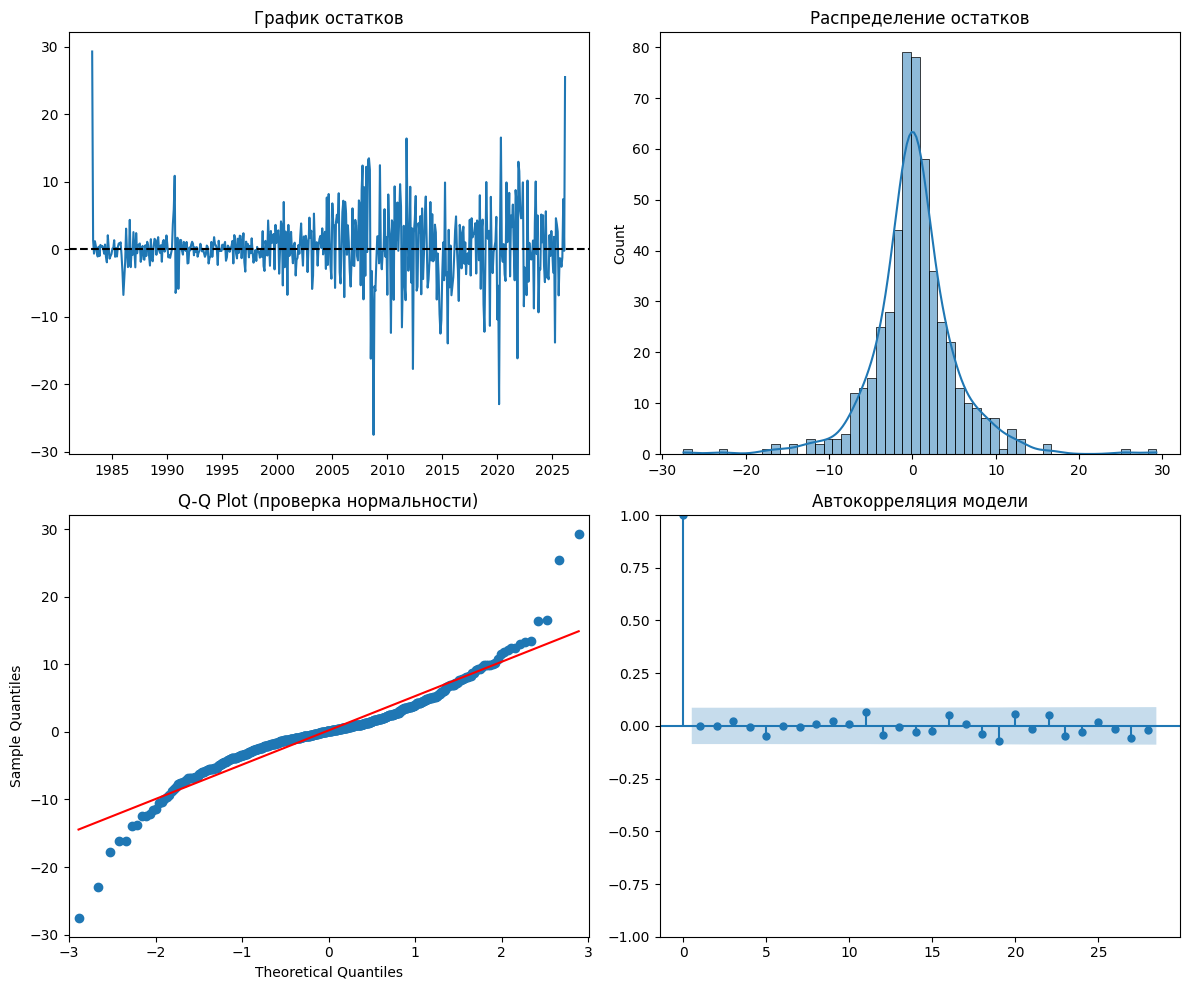

In [14]:
# Получаем остатки из обученной модели auto_arima
residuals = model_auto.resid()
# Построение графиков диагностики
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# График остатков во времени
axes[0, 0].plot(residuals)
axes[0, 0].set_title('График остатков')
axes[0, 0].axhline(0, color='black', linestyle='--')
# Гистограмма распределения (должна быть похожа на колокол — нормальное распределение)
import seaborn as sns
sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Распределение остатков')
# Q-Q Plot (точки должны лежать на диагонали)
from statsmodels.graphics.gofplots import qqplot
qqplot(residuals, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (проверка нормальности)')
# Автокорреляция остатков (ACF) - столбики не должны выходить за пределы синей зоны
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, ax=axes[1, 1])
axes[1, 1].set_title('Автокорреляция модели')
plt.tight_layout()
plt.show()

In [14]:
! pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.9 MB/s eta 0:00:00


Метод Холта-Уинтерса (тройное экспоненциальное сглаживание)

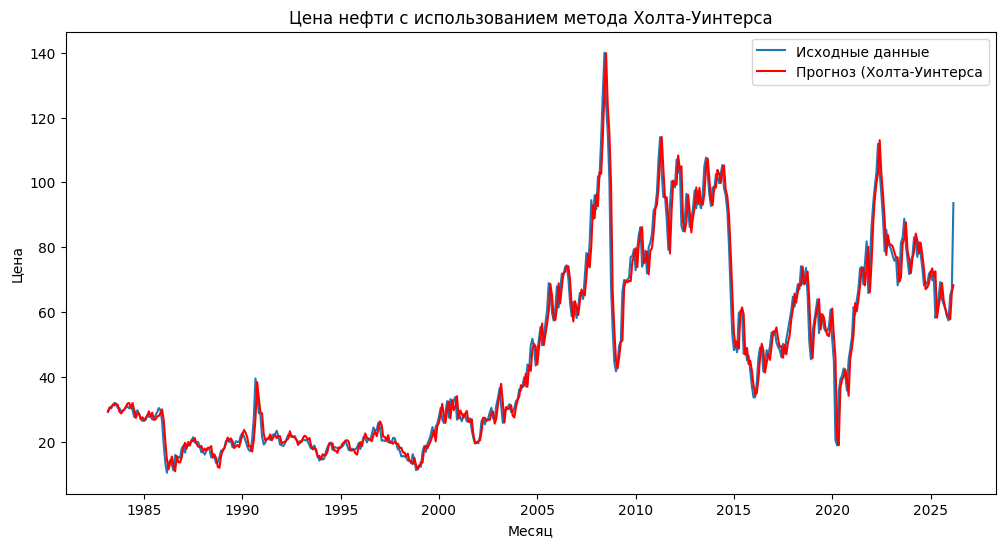

ПАРАМЕТРЫ СГЛАЖИВАНИЯ:
Alpha (уровень):   1.0000
Beta (тренд):      0.0000
Gamma (сезонность): 0.0000

Начальный уровень: 29.24
Начальный тренд:  0.12


In [15]:
model_hw = mod.model_hw(data)

#Извлекаем параметры сглаживания
params = model_hw.params

print("ПАРАМЕТРЫ СГЛАЖИВАНИЯ:")
print(f"Alpha (уровень):   {params['smoothing_level']:.4f}")
print(f"Beta (тренд):      {params['smoothing_trend']:.4f}")
print(f"Gamma (сезонность): {params['smoothing_seasonal']:.4f}")

# 3. Дополнительно: начальные значения компонентов
print(f"\nНачальный уровень: {params['initial_level']:.2f}")
print(f"Начальный тренд:  {params['initial_trend']:.2f}")

ПРОГНОЗ ХОЛТА-УИНТЕРСА НА КВАРТАЛ:
            Прогноз
2026-04-01    94.68
2026-05-01    94.75
2026-06-01    95.87


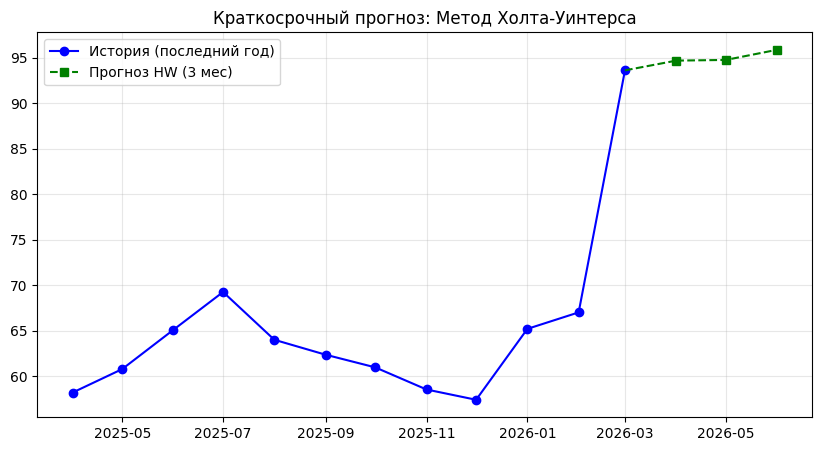

In [16]:
# Генерация прогноза на 3 месяца

mod.pred_modelHW(model_hw, data, 3)

**Проверка модели Холта-Уинтерса с помощью Rolling Forecast (прогнозом с переобучением)**

Месяц 1/12: Предсказано=72.89, Реально=58.21
Месяц 2/12: Предсказано=58.23, Реально=60.79
Месяц 3/12: Предсказано=61.83, Реально=65.11
Месяц 4/12: Предсказано=64.87, Реально=69.26
Месяц 5/12: Предсказано=69.10, Реально=64.01
Месяц 6/12: Предсказано=63.76, Реально=62.37
Месяц 7/12: Предсказано=61.24, Реально=60.98
Месяц 8/12: Предсказано=59.35, Реально=58.55
Месяц 9/12: Предсказано=58.79, Реально=57.42
Месяц 10/12: Предсказано=57.57, Реально=65.21
Месяц 11/12: Предсказано=66.12, Реально=67.02
Месяц 12/12: Предсказано=67.66, Реально=93.61

Средняя ошибка (MAE) скользящего прогноза: 5.69


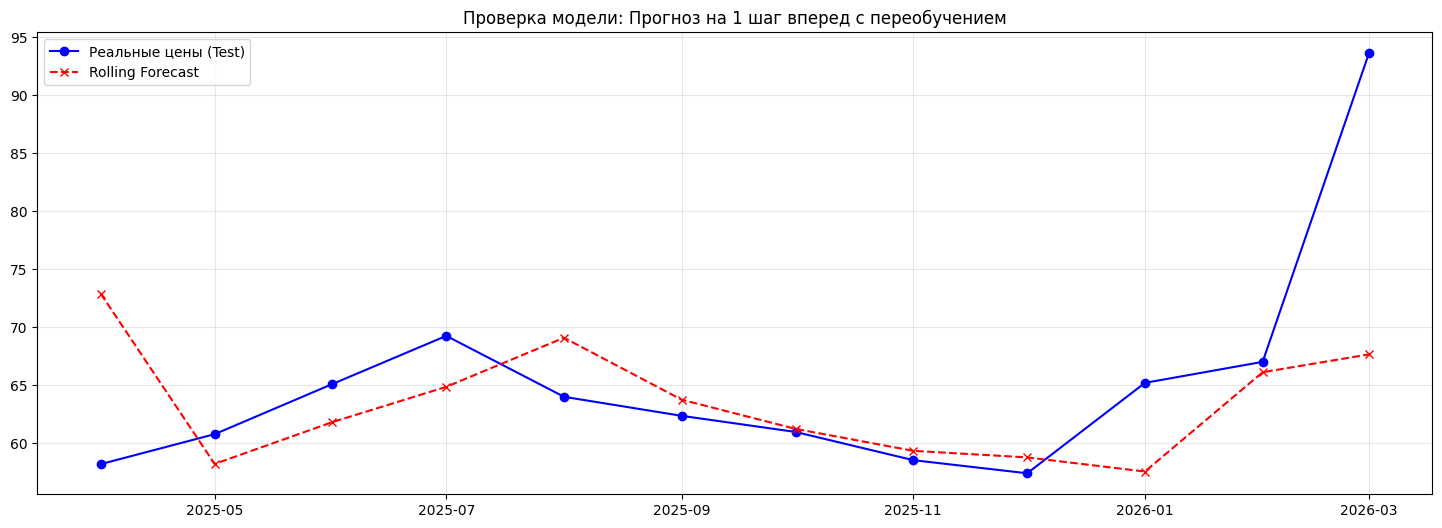

Функция вернула: 5.69


In [17]:
#Метрики модели Холта-Уинтерса

mae = mod.metricaHW(data)
#Добавляем в справочник ошибок
dict_models["Холт-Уинтерс"] = mae

print(f"Функция вернула: {mae}")


Подготовка данных и обучение модели LSTM

In [18]:
# Подготовка данных для модели LSTM:
from sklearn.preprocessing import MinMaxScaler
# Преобразование данных в массив NumPy
data_values = data['price'].values.reshape(-1, 1)

# Нормализуйте данные (масштабируйте в диапазон [0, 1])
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_values)

# Разделите данные на обучающую и тестовую выборки
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]


In [18]:
! pip install tensorflow

In [19]:
# Функция для создания последовательных данных для модели LSTM
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
def create_sequences(data, seq_length):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        sequence = data[i:i+seq_length]
        target = data[i+seq_length]
        sequences.append(sequence)
        targets.append(target)
    return np.array(sequences), np.array(targets)

# Определение длины последовательности и создание последовательных данных
seq_length = 12  # Например, используйте данные за последний год (12 месяцев)
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

# Создайте и обучите модель LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100


c:\Users\OITKostya\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0293   
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0072 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0051 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


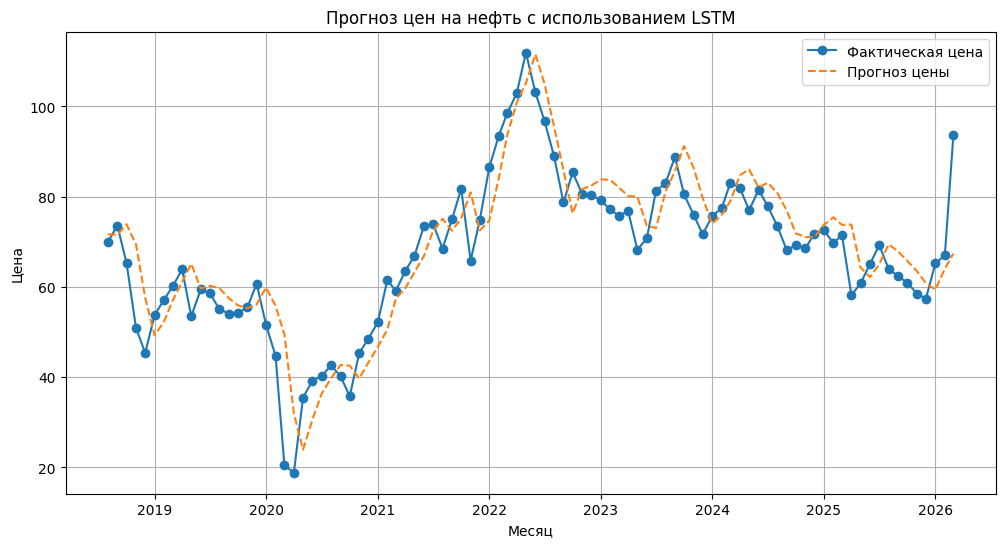

Mean Absolute Error (MAE): 6.068
Mean Squared Error (MSE): 61.251
Root Mean Squared Error (RMSE): 7.826


In [20]:
# Прогнозирование на тестовых данных
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)

# Инверсия масштабирования
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Визуализируйте результаты прогноза
plt.figure(figsize=(12, 6))
plt.plot(data.index[-len(y_test_inv):], y_test_inv, label='Фактическая цена', marker='o')
plt.plot(data.index[-len(y_test_inv):], y_pred_inv, label='Прогноз цены', linestyle='--')
plt.title("Прогноз цен на нефть с использованием LSTM")
plt.xlabel("Месяц")
plt.ylabel("Цена")
plt.legend()
plt.grid(True)
plt.show()

# Оценка точности прогноза
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)

#Добавляем в справочник ошибок
dict_models["LSTM"] = mae

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")


Прогноз на ближайшие 3 месяца:
            Прогноз_LSTM
2026-04-01     85.660004
2026-05-01     88.889999
2026-06-01     91.580002


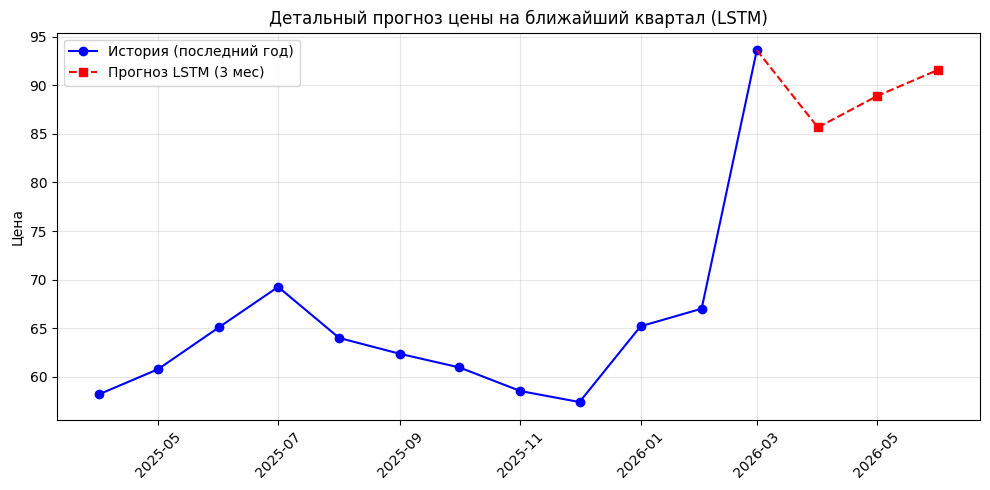

In [21]:
# Подготовка последнего доступного "окна" данных (последние 12 месяцев)

last_window = data_scaled[-12:].reshape(1, 12, 1)

# Список для хранения предсказаний
forecast_3m_scaled = []

# Цикл прогнозирования на 3 шага
current_input = last_window.copy()

for i in range(3):
    # Предсказание на 1 шаг вперед
    pred = model.predict(current_input, verbose=0) #!!!!!!
    forecast_3m_scaled.append(pred[0, 0])

    # Обновление входного окна: удаляем старый месяц, добавляем предсказанный
    # Новое значение вставляется в конец, форма массива: (1, 12, 1)
    new_entry = pred.reshape(1, 1, 1)
    current_input = np.append(current_input[:, 1:, :], new_entry, axis=1)

# Обратное масштабирование в реальные цены
forecast_3m = scaler.inverse_transform(np.array(forecast_3m_scaled).reshape(-1, 1))

# Создание дат для прогноза
last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')

# Вывод результата
forecast_df = pd.DataFrame(data=forecast_3m, index=forecast_dates, columns=['Прогноз_LSTM'])
print("Прогноз на ближайшие 3 месяца:")
print(forecast_df.round(2))

# Подготовка данных для графика
history_subset = data['price'][-12:] # Последние 12 месяцев для контекста
forecast_series = pd.Series(forecast_3m.flatten(), index=forecast_dates)

# Соединяем последнюю точку истории с первой точкой прогноза для непрерывности линии
connect_date = [history_subset.index[-1], forecast_series.index[0]]
connect_price = [history_subset.iloc[-1], forecast_series.iloc[0]]
# Построение графика
plt.figure(figsize=(10, 5))

# Отрисовка истории
plt.plot(history_subset.index, history_subset.values,
         label='История (последний год)', color='blue', marker='o')

# Отрисовка прогноза
plt.plot(forecast_series.index, forecast_series.values,
         label='Прогноз LSTM (3 мес)', color='red', linestyle='--', marker='s')

# Соединительная линия (пунктир)
plt.plot(connect_date, connect_price, color='red', linestyle='--')

plt.title('Детальный прогноз цены на ближайший квартал (LSTM)')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)
plt.legend()

# Настройка оси X для удобства чтения дат
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Использование модели SARIMAX для прогнозирования цены на нефть**

c:\Users\OITKostya\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


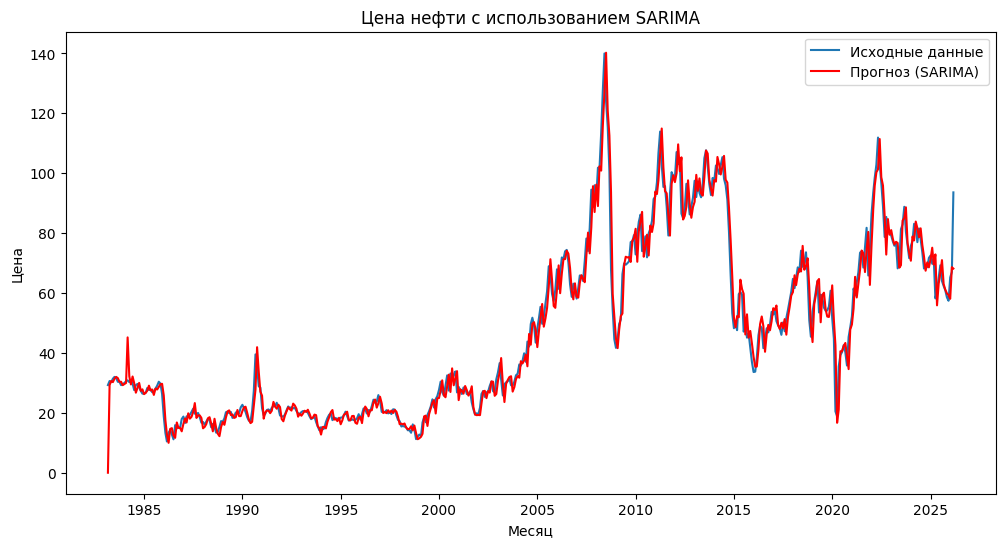

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
ts = data['price']

# Создаем и обучаем модель SARIMA
model_sarima = SARIMAX(ts, order=(4, 1, 3), seasonal_order=(4, 1, 3, 12))  # Пример параметров (p, d, q) и (P, D, Q, s)
results_sarima = model_sarima.fit()

# Визуализируем прогноз
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Исходные данные')
plt.plot(results_sarima.fittedvalues, color='red', label='Прогноз (SARIMA)')
plt.title("Цена нефти с использованием SARIMA")
plt.xlabel("Месяц")
plt.ylabel("Цена")
plt.legend()
plt.show()

ПРОГНОЗ SARIMA НА 3 МЕСЯЦА:
            Прогноз  Нижняя граница  Верхняя граница
2026-04-01   101.99           92.36           111.62
2026-05-01   102.90           87.99           117.81
2026-06-01   103.10           84.24           121.96


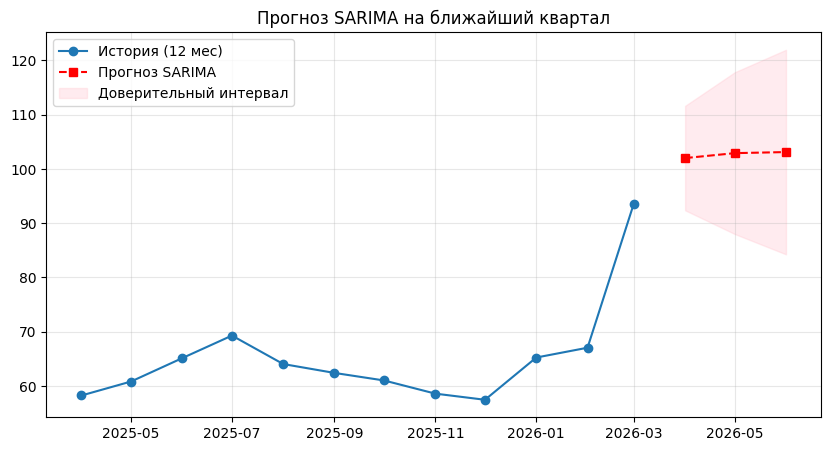

In [23]:
# Прогноз на 3 шага (месяца) вперед

forecast_obj = results_sarima.get_forecast(steps=3)

# Извлекаем средние значения прогноза
forecast_mean = forecast_obj.predicted_mean

# Извлекаем доверительные интервалы (по умолчанию 95%)
conf_int = forecast_obj.conf_int()

# Создание дат для прогноза
last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')
forecast_mean.index = forecast_dates
conf_int.index = forecast_dates

# Вывод таблицы
forecast_df = pd.concat([forecast_mean, conf_int], axis=1)
forecast_df.columns = ['Прогноз', 'Нижняя граница', 'Верхняя граница']
print("ПРОГНОЗ SARIMA НА 3 МЕСЯЦА:")
print(forecast_df.round(2))

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(data['price'][-12:], label='История (12 мес)', marker='o')
plt.plot(forecast_mean, label='Прогноз SARIMA', color='red', marker='s', linestyle='--')

# Закрашиваем зону неопределенности
plt.fill_between(forecast_dates,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Доверительный интервал')

plt.title('Прогноз SARIMA на ближайший квартал')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Проверка модели SARIMA с помощью Rolling Forecast (прогнозом с переобучением)**

c:\Users\OITKostya\venv\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\OITKostya\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Запуск скользящего прогноза (это может занять время)...
Месяц 1/12: Предсказано=74.34, Реально=58.21
Месяц 2/12: Предсказано=55.64, Реально=60.79
Месяц 3/12: Предсказано=63.27, Реально=65.11
Месяц 4/12: Предсказано=65.00, Реально=69.26
Месяц 5/12: Предсказано=71.75, Реально=64.01
Месяц 6/12: Предсказано=63.13, Реально=62.37
Месяц 7/12: Предсказано=60.25, Реально=60.98
Месяц 8/12: Предсказано=59.82, Реально=58.55
Месяц 9/12: Предсказано=58.79, Реально=57.42
Месяц 10/12: Предсказано=57.97, Реально=65.21
Месяц 11/12: Предсказано=69.81, Реально=67.02
Месяц 12/12: Предсказано=64.68, Реально=93.61
MAE 6.52

Средняя ошибка (MAE) скользящего прогноза: 6.52


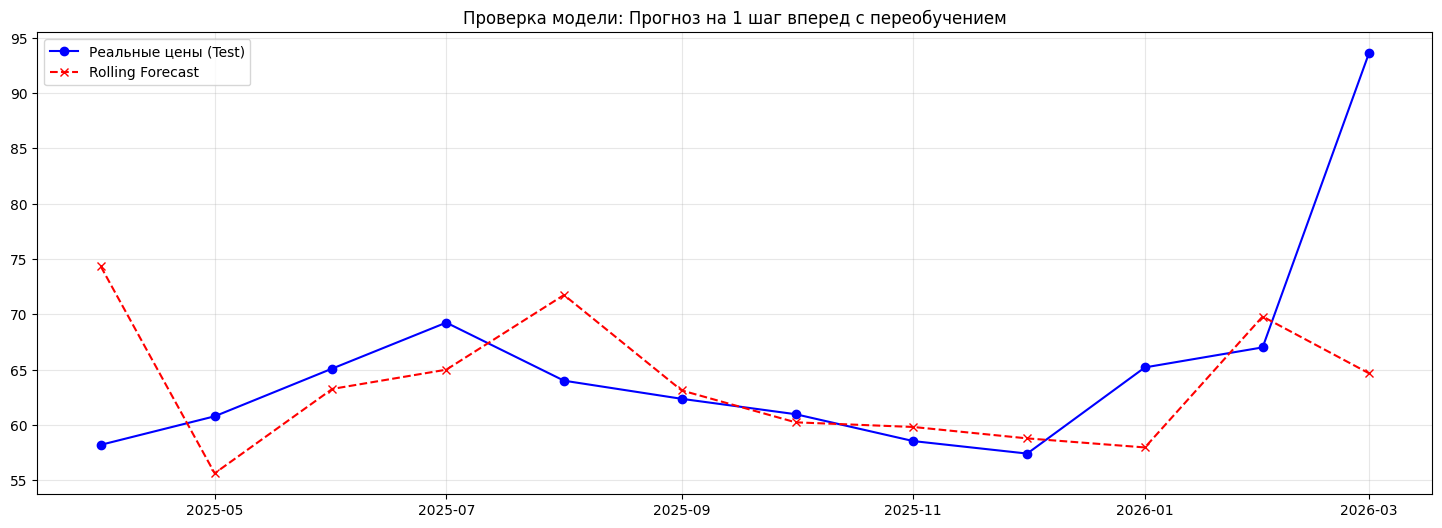

6.52


In [24]:
#Метрики и прогнозы модели SARIMA
metric = mod.metricaSARIMA(data)
#Добавляем в справочник ошибок
print(metric)
dict_models["SARIMA"] = metric


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2314  
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1422 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0811 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0508 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0387 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0293 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0248 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0200 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0165 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0156 
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0146 
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

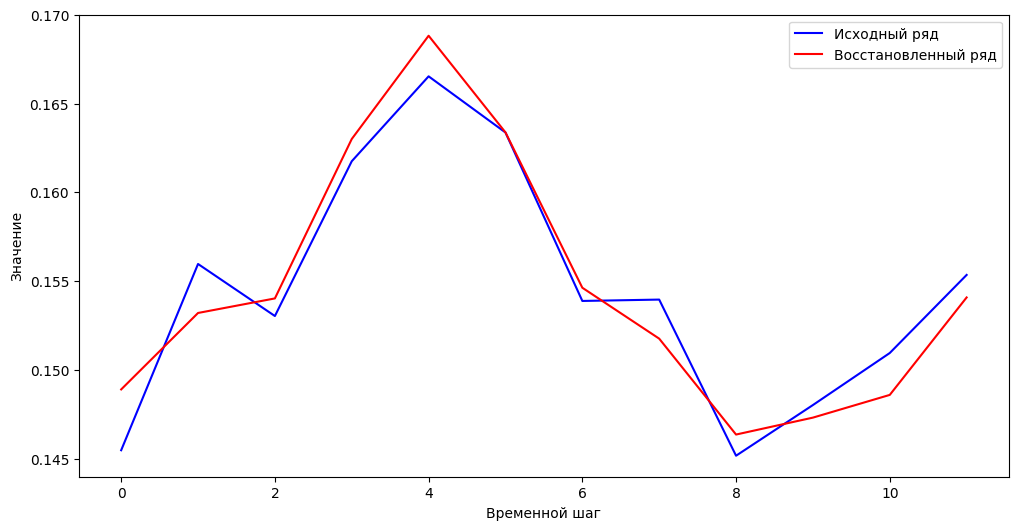

In [25]:
# Автоэнкодер
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
timesteps = 12
# Создание автоэнкодера
input_layer = Input(shape=(timesteps,))
encoded = Dense(100, activation='relu')(input_layer)  # Скрытое представление с 50 нейронами
decoded = Dense(timesteps, activation='linear')(encoded)  # Восстановление исходных данных

autoencoder = Model(input_layer, decoded)

# Компиляция модели
autoencoder.compile(optimizer='adam', loss='mean_absolute_error')

# Обучение автоэнкодера
autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, shuffle=True)

# Использование обученного автоэнкодера для сжатия и восстановления временных рядов
encoded_data = autoencoder.predict(X_train)
encoded_data_reshaped = np.expand_dims(encoded_data, axis=-1)

mae_eval = autoencoder.evaluate(X_train, X_train, verbose=0)

print(f"MAE (через evaluate): {mae_eval:.5f}")

# Считаем среднюю абсолютную разницу между оригиналом и восстановлением
mae_total = np.mean(np.abs(X_train - encoded_data_reshaped), axis=(1, 2))

print(f"Средняя MAE по всем данным: {np.mean(mae_total):.4f}")
#Добавляем в справочник ошибок
dict_models["Autoencoder"] = mae_eval


# Визуализация исходных и восстановленных данных
import matplotlib.pyplot as plt

index = 0  # Индекс временного ряда для визуализации
plt.figure(figsize=(12, 6))
plt.plot(X_train[index], label='Исходный ряд', color='blue')
plt.plot(encoded_data[index], label='Восстановленный ряд', color='red')
plt.xlabel('Временной шаг')
plt.ylabel('Значение')
plt.legend()
plt.show()

In [26]:
# Подготовка последнего окна (12 месяцев)

current_window = data_scaled[-12:].reshape(1, 12, 1)

forecast_steps = 3
ae_forecast_scaled = []

# Рекурсивный цикл прогноза
for i in range(forecast_steps):
    # Автоэнкодер восстанавливает (очищает) текущее окно
    reconstructed_window = autoencoder.predict(current_window, verbose=0)

    # Берем последнее значение из восстановленного окна как прогноз на t+1
    next_step = reconstructed_window[0, -1]
    ae_forecast_scaled.append(next_step)

    # Обновляем окно: сдвигаем и добавляем новый прогноз в конец
    new_entry = np.array(next_step).reshape(1, 1, 1)
    current_window = np.append(current_window[:, 1:, :], new_entry, axis=1)

# Обратное масштабирование
ae_forecast = scaler.inverse_transform(np.array(ae_forecast_scaled).reshape(-1, 1))

# Формирование дат
last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')

print("ПРОГНОЗ АВТОЭНКОДЕРА НА 3 МЕСЯЦА:")
print(pd.DataFrame({'Прогноз': ae_forecast.flatten()}, index=forecast_dates).round(2))



ПРОГНОЗ АВТОЭНКОДЕРА НА 3 МЕСЯЦА:
              Прогноз
2026-04-01  92.730003
2026-05-01  92.849998
2026-06-01  92.720001


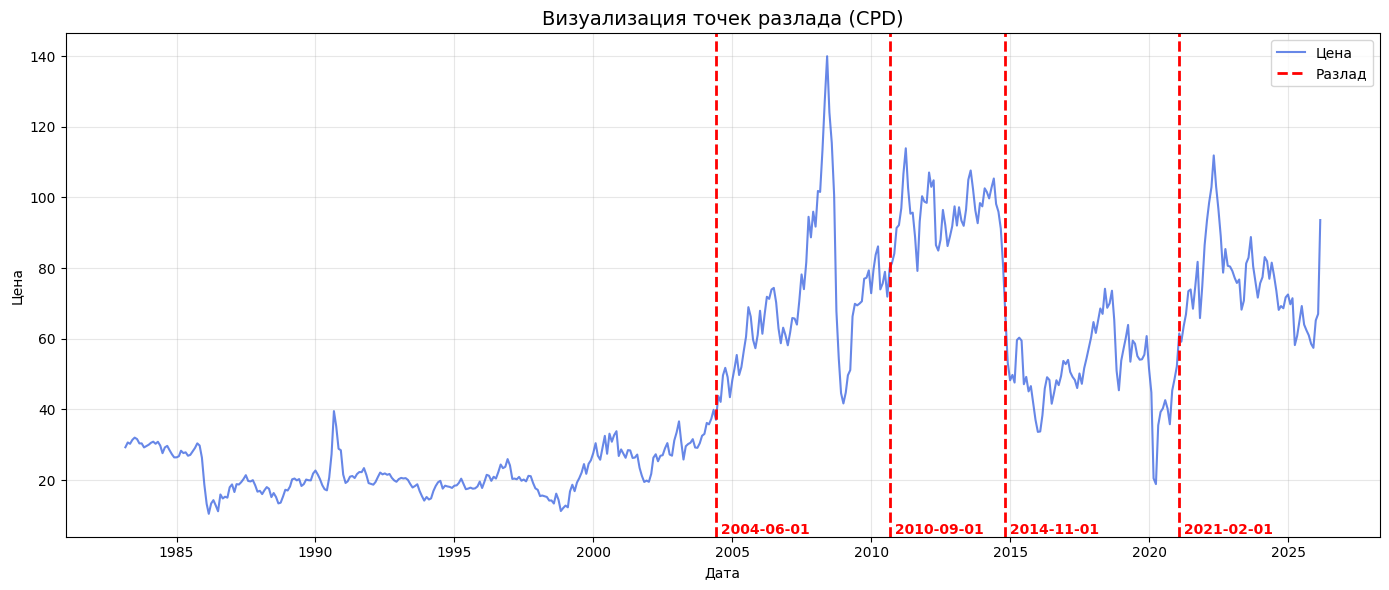

Даты значительных изменений в структуре ряда:
DatetimeIndex(['2004-06-01', '2010-09-01', '2014-11-01', '2021-02-01'], dtype='datetime64[ns]', name='date', freq=None)


In [27]:
import ruptures as rpt

# Подготовка данных (преобразуем в numpy массив)
points = data['price'].values

# Выбор алгоритма (Pelt — один из самых точных для поиска нескольких точек)
# "rbf" — ищет изменение динамики/вариативности
algo = rpt.Pelt(model="rbf").fit(points)

# Предсказание точек (pen — штраф за количество точек, подбирается опытным путем)
# Чем меньше pen, тем больше точек найдет алгоритм
result = algo.predict(pen=10)
change_dates = data.index[result[:-1]] # исключаем последнюю точку

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['price'], label='Цена', color='royalblue', alpha=0.8)

# Добавляем вертикальные линии и подписи дат
for cp_date in change_dates:
    plt.axvline(x=cp_date, color='red', linestyle='--', linewidth=2, label='Разлад' if cp_date == change_dates[0] else "")
    # Добавляем текст даты сверху
    plt.text(cp_date, plt.ylim()[0], f' {cp_date.strftime("%Y-%m-%d")}',
             color='red', fontweight='bold', verticalalignment='bottom')

plt.title('Визуализация точек разлада (CPD)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Печать дат, когда произошли изменения

print("Даты значительных изменений в структуре ряда:")
print(change_dates)

In [28]:
#Сравнение метрики MAE для моделей
print(dict_models)

{'ARIMA': 4.501499141196963, 'Холт-Уинтерс': 5.69, 'LSTM': 6.068185960587214, 'SARIMA': 6.52, 'Autoencoder': 0.003099677385762334}


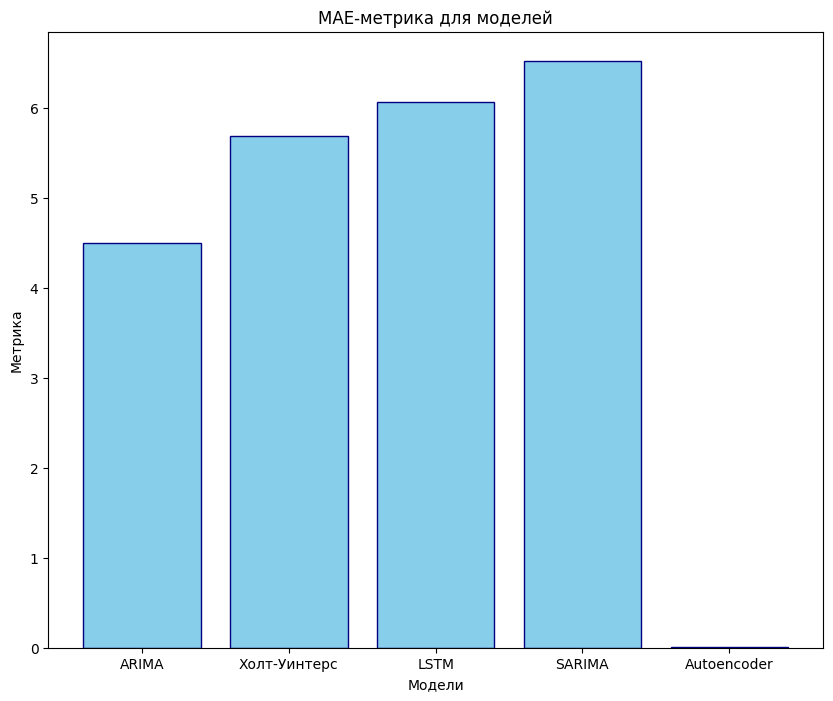

In [30]:
plt.bar(dict_models.keys(), dict_models.values(), color='skyblue', edgecolor='navy')

plt.title('MAE-метрика для моделей')
plt.xlabel('Модели')
plt.ylabel('Метрика')
plt.show()

Анализ данных с помощью различных моделей машинного обучения показал, что прогнозирование цен на нефть может дать вполне приемлемый результат. 18 марта 2026 года цены на сырую нефть марки Brent держались выше отметки
$103 за баррель, демонстрируя рост из-за опасений по поводу перебоев в поставках. На фоне ближневосточных рисков и высокого спроса, цены удерживаются выше критического уровня $100. Прогноз модели SARIMA на 01.04.2026 - $101.99. Анализ точек разлада временного ряда показывает, что на данный момент цена держится в последнем тренде начиная с 01.02.2021 года. Тогда Мировое производство нефти росло медленнее, чем спрос, что привело к повышению цены вплоть до самой высокой за посление 3 года в мае 2022 года. Тем не менее, согласно глобальным макромоделям Trading Economics, цена на сырую нефть составит 99,27 USD/BBL к концу этого квартала

Прогноз моделей на 2 квартал 2026 года

АВТОЭНКОДЕР	SARIMA	LSTM	Холт-Уинтерс	ARIMA
92.73	101.99  	85.66	94.68 	98.77
92.85	102.90 	88.89	94.75 	100.02
92.72	103.10 	91.58	95.87	99.48


